In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
 df = pd.read_csv("/home/wieger/Documents/Research/Omnisketch/omni/output/pointQueries/CAIDA/results_Test Two LHS_CAIDA_2024-01-08 13:40:50_Rep2.csv")

In [21]:
df.columns

Index(['totalStreamSize', 'numAttributes', 'memUsageDataset', 'RAM', 'setting',
       'Avg Update Time', 'memUsageSynopsis', 'parameters',
       'numAttributesInWorkload', 'queryID', 'numPredicates', 'exactAnswer',
       'estimate', 'absError', 'relError', 'epsError', 'withinThreshold',
       'estTime', 'queryText', 'streamSizeAfterDeletes', 'unionSize'],
      dtype='object')

## Estimate over answer size

<Axes: >

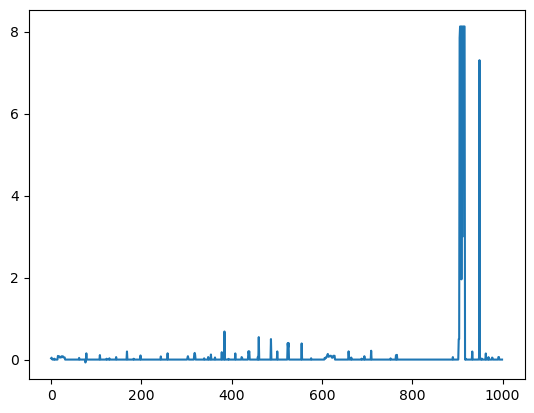

In [22]:
(df['estimate']/df['exactAnswer']).plot()


## Error per number of predicates

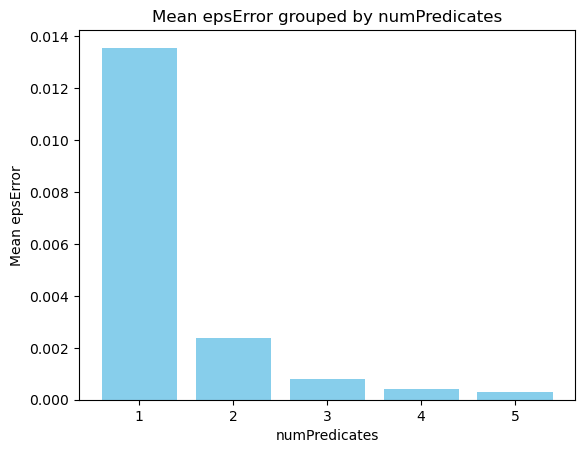

In [23]:
grouped_df = df.groupby('numPredicates')['epsError'].mean().reset_index()

# Plotting
plt.bar(grouped_df['numPredicates'], grouped_df['epsError'], color='skyblue')
plt.xlabel('numPredicates')
plt.ylabel('Mean epsError')
plt.title('Mean epsError grouped by numPredicates')
plt.show()

## Estimate per number of predicates

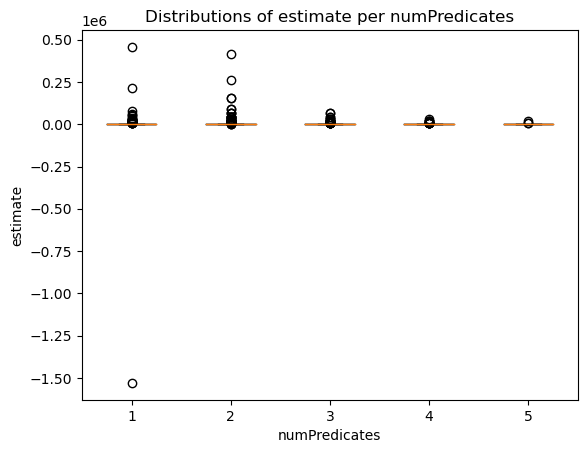

In [28]:
data = [df[df['numPredicates'] == group]['estimate'] for group in df['numPredicates'].unique()]

# Plotting boxplots
plt.boxplot(data, labels=df['numPredicates'].unique())
plt.xlabel('numPredicates')
plt.ylabel('estimate')
plt.title('Distributions of estimate per numPredicates')
plt.show()

In [31]:
dfmin = df[df['estimate'] < 0]
dfmin[['queryText', 'unionSize','estimate','exactAnswer','absError']]

,queryText,unionSize,estimate,exactAnswer,absError
76,"ipProto=6,",21611741,-1530002,21611741,23141743


## Exact Answer per number of predicates

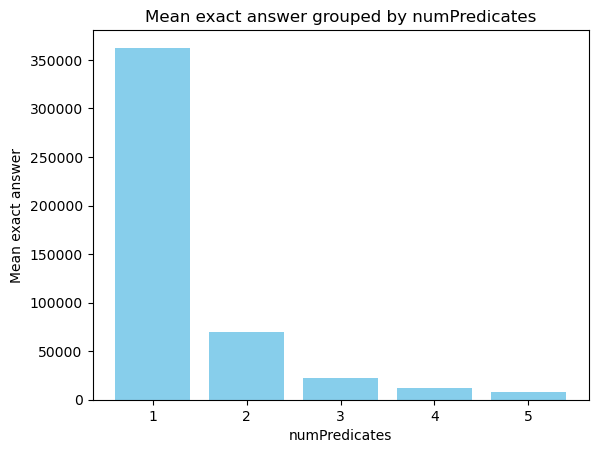

In [25]:
grouped_df = df.groupby('numPredicates')['exactAnswer'].mean().reset_index()

# Plotting
plt.bar(grouped_df['numPredicates'], grouped_df['exactAnswer'], color='skyblue')
plt.xlabel('numPredicates')
plt.ylabel('Mean exact answer')
plt.title('Mean exact answer grouped by numPredicates')
plt.show()

In [27]:
df['estimate']

0      12115
1      54342
2       4578
3          0
4          0
       ...  
995        0
996        0
997        0
998        0
999        0
Name: estimate, Length: 1000, dtype: int64